# Normalisation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('wine.csv',header=None,usecols=[0,1,2])
df.columns=['class level','Alcohol','Malic acid']  # this is the ways of changing the name of columns
df = df.drop(0,axis=0)

In [3]:
df.head()

,class level,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95
5,1,13.24,2.59


In [38]:
df.shape[0]

178

In [4]:
df.size

534

In [5]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [6]:
df

,class level,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95
5,1,13.24,2.59
...,...,...,...
174,3,13.71,5.65
175,3,13.4,3.91
176,3,13.27,4.28
177,3,13.17,2.59


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 1 to 178
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   class level  178 non-null    object
 1   Alcohol      178 non-null    object
 2   Malic acid   178 non-null    object
dtypes: object(3)
memory usage: 4.3+ KB


# Note -> We can not draw KDE plot for catagorical data columns

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

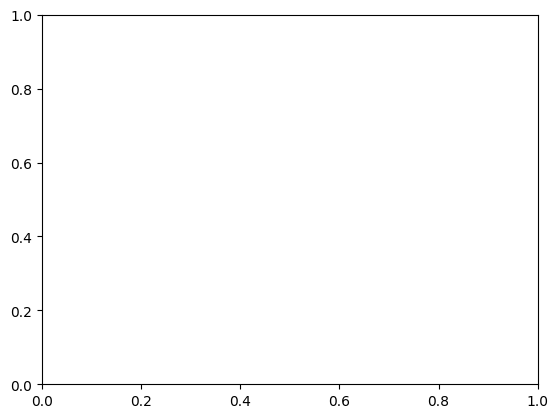

In [22]:

sns.kdeplot(df['Alcohol'])

In [7]:
print(df['Alcohol'].dtype)  # Note -> convert the object datatype to numerical first before applying the kdeplot

object


In [8]:
df['Alcohol'] = df['Alcohol'].astype(float)

In [9]:
print(df['class level'].dtype)

object


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 1 to 178
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   class level  178 non-null    object 
 1   Alcohol      178 non-null    float64
 2   Malic acid   178 non-null    object 
dtypes: float64(1), object(2)
memory usage: 4.3+ KB


In [11]:
df['Malic acid'] = df['Malic acid'].astype(float)

In [12]:
df

,class level,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.20,1.78
3,1,13.16,2.36
4,1,14.37,1.95
5,1,13.24,2.59
...,...,...,...
174,3,13.71,5.65
175,3,13.40,3.91
176,3,13.27,4.28
177,3,13.17,2.59


In [13]:
df['class level'] = df['class level'].astype('category')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 1 to 178
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   class level  178 non-null    category
 1   Alcohol      178 non-null    float64 
 2   Malic acid   178 non-null    float64 
dtypes: category(1), float64(2)
memory usage: 3.2 KB


<Axes: xlabel='Malic acid', ylabel='Density'>

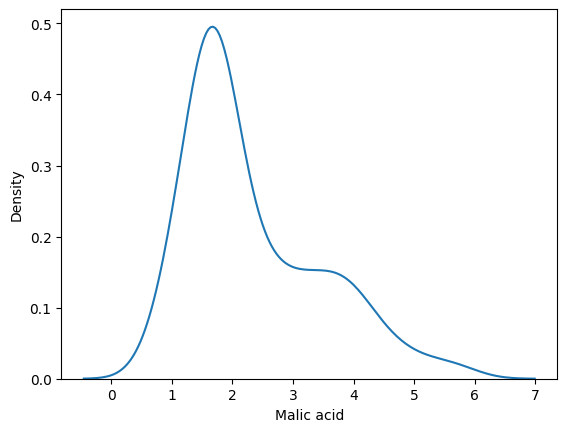

In [16]:
sns.kdeplot(df['Malic acid'])

<Axes: xlabel='Alcohol', ylabel='Malic acid'>

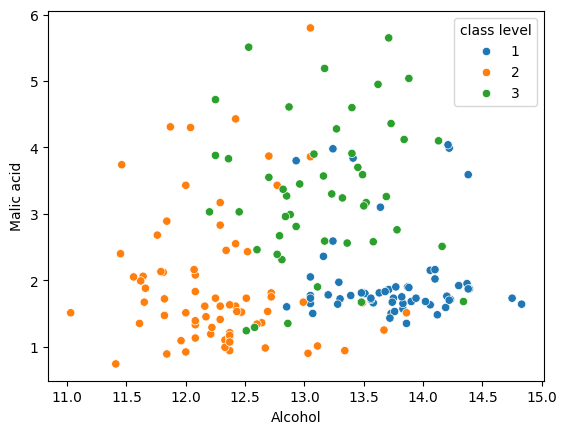

In [17]:
sns.scatterplot(
    x=df['Alcohol'],
    y=df['Malic acid'],
    hue=df['class level']
)

In [20]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(df.drop('class level',axis=1),df['class level'],test_size=0.3,random_state=42)

In [39]:
x_train.shape[0]

124

In [23]:
x_train

,Alcohol,Malic acid
139,13.49,3.59
105,12.51,1.73
79,12.33,0.99
37,13.28,1.64
94,12.29,2.83
...,...,...
72,13.86,1.51
107,12.25,1.73
15,14.38,1.87
93,12.69,1.53


In [40]:
x_test.shape[0]

54

In [31]:
x_test

,Alcohol,Malic acid
20,13.64,3.10
46,14.21,4.04
141,12.93,2.81
31,13.73,1.50
68,12.37,1.17
17,14.30,1.92
120,12.00,3.43
175,13.40,3.91
110,11.61,1.35
142,13.36,2.56


In [25]:
print(df['class level'].dtype)
# df['x_train'].dtype


category


In [41]:
y_train.shape[0]

124

In [33]:
y_train

139    3
105    2
79     2
37     1
94     2
      ..
72     2
107    2
15     1
93     2
103    2
Name: class level, Length: 124, dtype: category
Categories (3, object): ['1', '2', '3']

In [42]:
y_test.shape[0]

54

In [34]:
y_test

20     1
46     1
141    3
31     1
68     2
17     1
120    2
175    3
110    2
142    3
25     1
151    3
42     1
119    2
16     1
112    2
114    2
83     2
10     1
115    2
19     1
67     2
61     2
170    3
172    3
165    3
118    2
66     2
91     2
56     1
30     1
129    2
146    3
32     1
13     1
43     1
159    3
138    3
99     2
160    3
39     1
109    2
86     2
69     2
144    3
3      1
101    2
123    2
155    3
52     1
77     2
57     1
27     1
154    3
Name: class level, dtype: category
Categories (3, object): ['1', '2', '3']

In [37]:
x_train.size

248

In [46]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# fit the scaler to the train data it will learn the parameter
scaler.fit(x_train)
#transform both train and test data
x_train_scale = scaler.transform(x_train)
x_test_scale = scaler.transform(x_test)
# Note -> It converts your data into numpy array. We need do convert this again in dataframe

In [47]:
# Making again dataframe of the scaled data
x_train_scale = pd.DataFrame(x_train_scale,columns=x_train.columns)
x_test_scale = pd.DataFrame(x_test_scale,columns=x_test.columns)
# Here columns=x_train.columns this command is used for taking the name of the column from the original tables

In [49]:
x_train_scale.shape[0]

124

In [53]:
# describing the previous data
np.round(x_train.describe(),2)

,Alcohol,Malic acid
count,124.00,124.00
mean,12.96,2.40
std,0.84,1.10
min,11.03,0.89
25%,12.29,1.64
50%,12.94,1.90
75%,13.70,3.17
max,14.83,5.80


In [54]:
np.round(x_train_scale.describe(),2)

,Alcohol,Malic acid
count,124.00,124.00
mean,0.51,0.31
std,0.22,0.22
min,0.00,0.00
25%,0.33,0.15
50%,0.50,0.21
75%,0.70,0.46
max,1.00,1.00


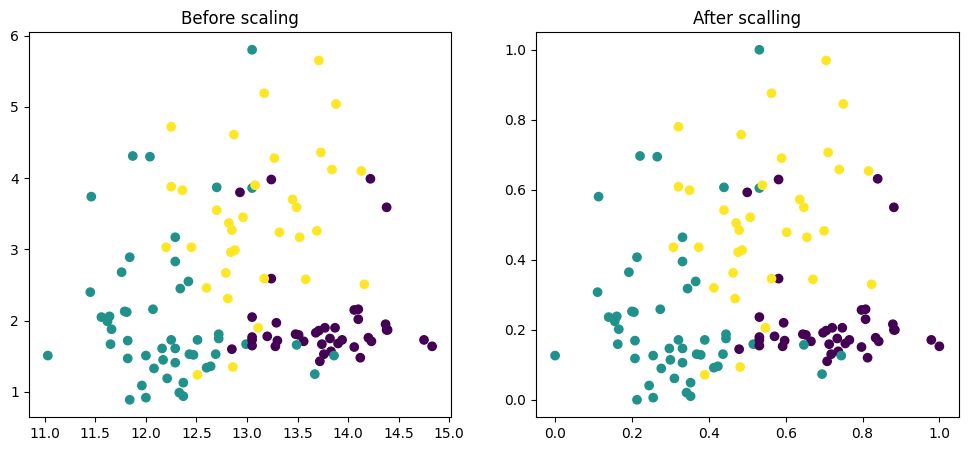

In [58]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_train['Alcohol'],x_train['Malic acid'],c=y_train.astype(int))
ax1.set_title("Before scaling")
ax2.scatter(x_train_scale['Alcohol'],x_train_scale['Malic acid'],c=y_train.astype(int))
ax2.set_title('After scalling')
plt.show()

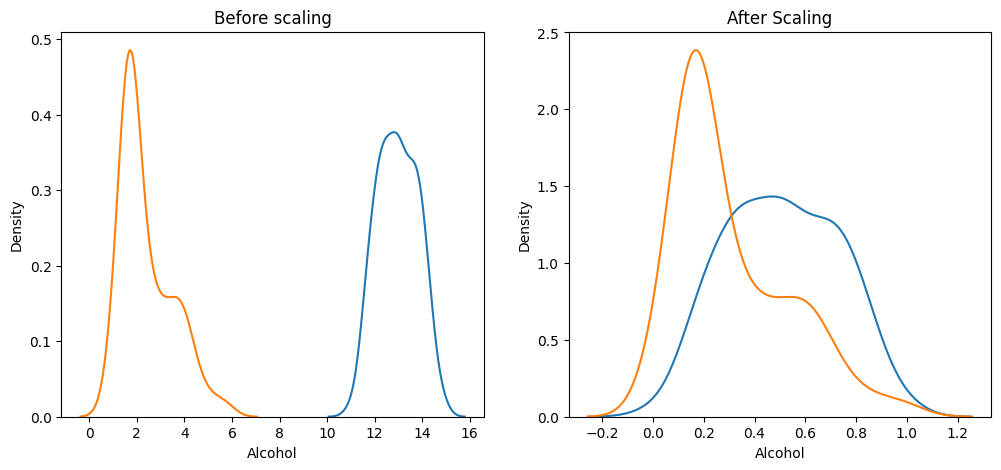

In [60]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
#before scalling
ax1.set_title("Before scaling")
sns.kdeplot(x_train['Alcohol'],ax=ax1)  # here ax=ax1 tell where to draw the graph
sns.kdeplot(x_train['Malic acid'],ax=ax1)

#After scaling
ax2.set_title("After Scaling")
sns.kdeplot(x_train_scale['Alcohol'],ax=ax2)
sns.kdeplot(x_train_scale['Malic acid'],ax=ax2)
plt.show()

<Axes: title={'center': 'After scalling the data'}, xlabel='Alcohol', ylabel='Density'>

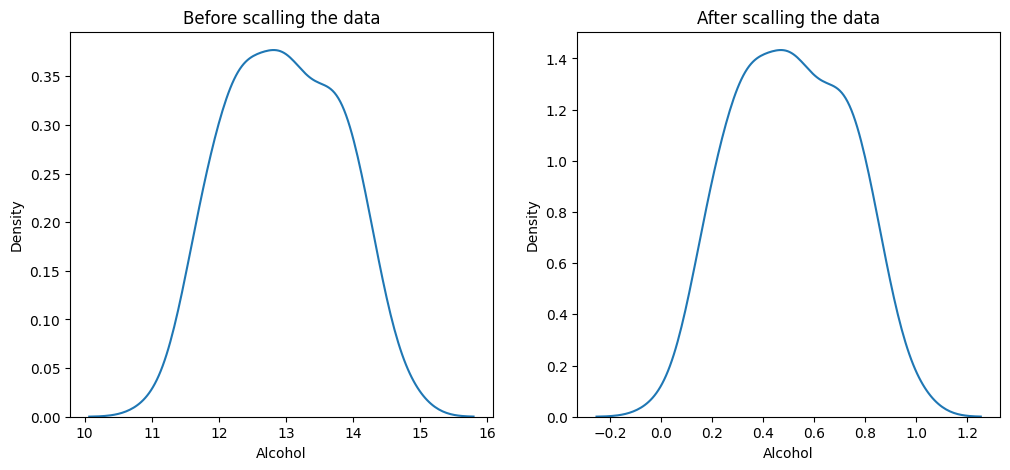

In [62]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
#Before scaling
ax1.set_title("Before scalling the data")
sns.kdeplot(x_train['Alcohol'],ax=ax1)

# After scalling data 
ax2.set_title("After scalling the data")
sns.kdeplot(x_train_scale['Alcohol'],ax=ax2)

<Axes: title={'center': 'After scaling data'}, xlabel='Malic acid', ylabel='Density'>

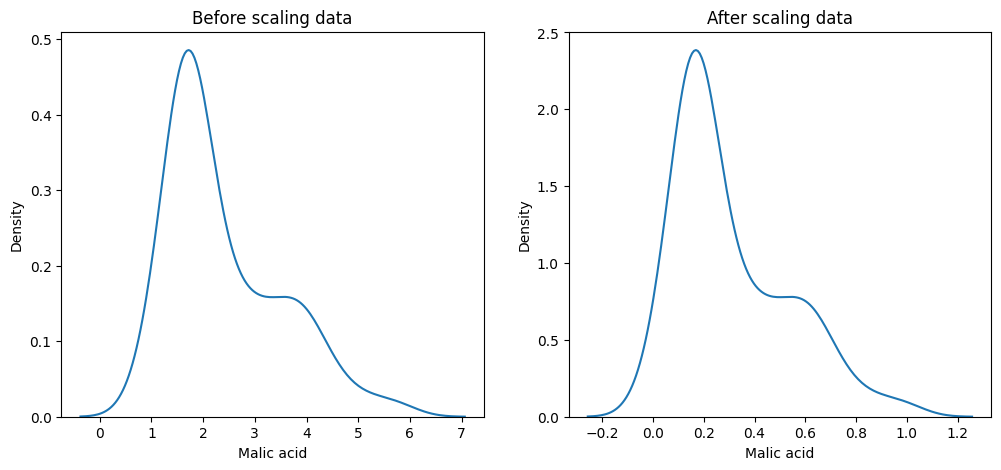

In [64]:
fig,(ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))
# Before scalling data 
ax1.set_title("Before scaling data")
sns.kdeplot(x_train['Malic acid'],ax=ax1)

# After scalling data
ax2.set_title("After scaling data")
sns.kdeplot(x_train_scale['Malic acid'],ax=ax2)


In [65]:
! git status


On branch main
Changes not staged for commit:
  (use "git add/rm <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	deleted:    Standarization.ipynb

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	.ipynb_checkpoints/
	Iris.csv
	Normalization.ipynb
	ads.csv
	day21.ipynb
	day22.html
	day22.ipynb
	day24.ipynb
	day26.ipynb
	day27.ipynb
	day28.ipynb
	day29.ipynb
	day30.ipynb
	flight.csv
	report.html
	tips.csv
	titanic.csv
	wine.csv

no changes added to commit (use "git add" and/or "git commit -a")
